In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/raw/player_season_24_25_data.csv')

In [9]:
print("Shape of dataset: ", df.shape)
print("\nLeague:\n", df['Comp'].value_counts())
print("\nTop 20 position values:\n", df['Pos'].value_counts().head(20))
print("\nDuplicate player+league rows:", df.duplicated(subset=['Player','Comp']).sum())
print("\nTotal unique players:", df['Player'].nunique())

Shape of dataset:  (2854, 267)

League:
 Comp
it Serie A            634
es La Liga            601
eng Premier League    574
fr Ligue 1            553
de Bundesliga         492
Name: count, dtype: int64

Top 20 position values:
 Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64

Duplicate player+league rows: 82

Total unique players: 2702


In [10]:
# These are the suffixes FBref appends to duplicated metadata columns
duplicate_suffixes = [
    '_stats_shooting', '_stats_passing', '_stats_passing_types',
    '_stats_gca', '_stats_defense', '_stats_possession',
    '_stats_playing_time', '_stats_misc', '_stats_keeper', '_stats_keeper_adv'
]

cols_to_drop = [
    c for c in df.columns
    if any(sfx in c for sfx in duplicate_suffixes)
]

df_clean = df.drop(columns=cols_to_drop)
print("Columns remaining:", df_clean.shape[1])
print(df_clean.columns.tolist())

Columns remaining: 149
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'G+A-PK', 'xG+xAG', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'Live', 'Dead', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Off', 'Blocks', 'SCA', 'SCA90', 'PassLive', 'PassDead', 'TO', 'Fld', 'Def', 'GCA', 'GCA90', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Tkl%', 'Lost', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Touches', 'Def Pen', 'Att Pen', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'CPA', 'Mis', 'Dis', 'Rec', 'Mn/MP', 'Min%', 'Mn/Start', 'Compl', 'Subs', 'Mn/Sub', 'unSub', 'PPM', 'onG', 'onGA', '+/-', '+/-90', 'On-Off', 'onxG', 'onxGA', 'xG+/-', 'xG+/-90', '2CrdY', 'Fls', 'PKwon', 'PKcon', '

In [12]:
df_clean = df_clean.copy()
df_clean['PrimaryPos'] = df_clean['Pos'].str.split(',').str[0]
print("Primary positions:\n", df_clean['PrimaryPos'].value_counts())

Primary positions:
 PrimaryPos
DF    1022
MF     900
FW     720
GK     212
Name: count, dtype: int64


In [13]:
df_clean = (df_clean
            .sort_values('Min', ascending=False)
            .drop_duplicates(subset=['Player'], keep='first')
            .reset_index(drop=True))

print("After dedup:", len(df_clean), "players")

After dedup: 2702 players


In [17]:
df_clean = df_clean[df_clean['Min'] >= 300].reset_index(drop=True)

print("After 300-min filter:", len(df_clean), "players")
print("Per league:\n", df_clean['Comp'].value_counts())
print("Per position:\n", df_clean['PrimaryPos'].value_counts())

After 300-min filter: 1896 players
Per league:
 Comp
es La Liga            419
it Serie A            409
eng Premier League    379
fr Ligue 1            351
de Bundesliga         338
Name: count, dtype: int64
Per position:
 PrimaryPos
DF    729
MF    585
FW    438
GK    144
Name: count, dtype: int64


In [19]:
# Rate stats — already per-90 from FBref, use directly
RATE_FEATURES = [
    'Sh/90', 'SoT/90', 'SCA90', 'GCA90',    # attacking threat
    'G/Sh', 'G/SoT',                          # finishing efficiency
]

# Counting stats — need to be divided by 90s to get per-90 rates
COUNT_FEATURES = [
    'Gls', 'Ast', 'xG', 'npxG', 'xAG',
    'PrgC', 'PrgP', 'PrgR',
    'Sh', 'SoT',
    'KP', 'PPA', 'CrsPA',
    'Tkl', 'TklW', 'Int', 'Clr', 'Err',  # Blocks_stats_defense removed
    'Recov',
    'Won',                                  # Lost_stats_misc removed
    'Carries', 'Succ', 'Tkld',
    'Touches', 'Mis', 'Dis',
]

# GK-specific columns (will only be non-zero for GKs)
GK_FEATURES = [
    'GA90', 'Save%', 'CS%',
    'PSxG+/-', '#OPA/90',
    'Stp%', 'AvgDist',
]

# Non-divisible rate/percentage columns
PCT_FEATURES = [
    'Cmp%',      # pass completion
    'Tkl%',      # tackle success
    'Succ%',     # dribble success
    'Won%',      # aerial duel win %
    'SoT%',      # shot accuracy
]

ALL_FEATURES = RATE_FEATURES + COUNT_FEATURES + GK_FEATURES + PCT_FEATURES

# Verify all columns exist
missing = [f for f in ALL_FEATURES if f not in df_clean.columns]
print("Missing columns:", missing)


Missing columns: []


In [20]:
df_feat = df_clean.copy()

# Divide all counting stats by 90s to get per-90 rates
# Avoid division by zero — players with 0 90s shouldn't be here after the filter
for col in COUNT_FEATURES:
    if col in df_feat.columns:
        df_feat[col + '_p90'] = df_feat[col] / df_feat['90s']

# Build final feature matrix column names
COUNT_P90 = [c + '_p90' for c in COUNT_FEATURES if c in df_feat.columns]
FINAL_FEATURES = RATE_FEATURES + COUNT_P90 + GK_FEATURES + PCT_FEATURES
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df_feat.columns]

print("Total features for clustering:", len(FINAL_FEATURES))

Total features for clustering: 44


In [21]:
from sklearn.preprocessing import StandardScaler

# Extract feature matrix
X = df_feat[FINAL_FEATURES].copy()

# Fill NaN with 0 — GK stats are blank for outfield players and vice versa
X = X.fillna(0)

# Z-score standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Any NaN remaining:", np.isnan(X_scaled).any())

Feature matrix shape: (1896, 44)
Any NaN remaining: False


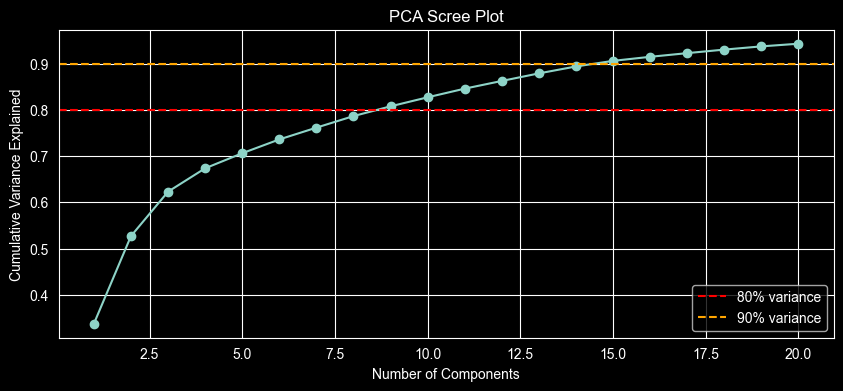

Variance explained by first 10 PCs: 0.828


In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# Scree plot — see how many components to keep
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), cumvar, marker='o')
plt.axhline(0.80, color='red', linestyle='--', label='80% variance')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Scree Plot')
plt.legend()
plt.grid(True)
plt.show()

print("Variance explained by first 10 PCs:", cumvar[9].round(3))

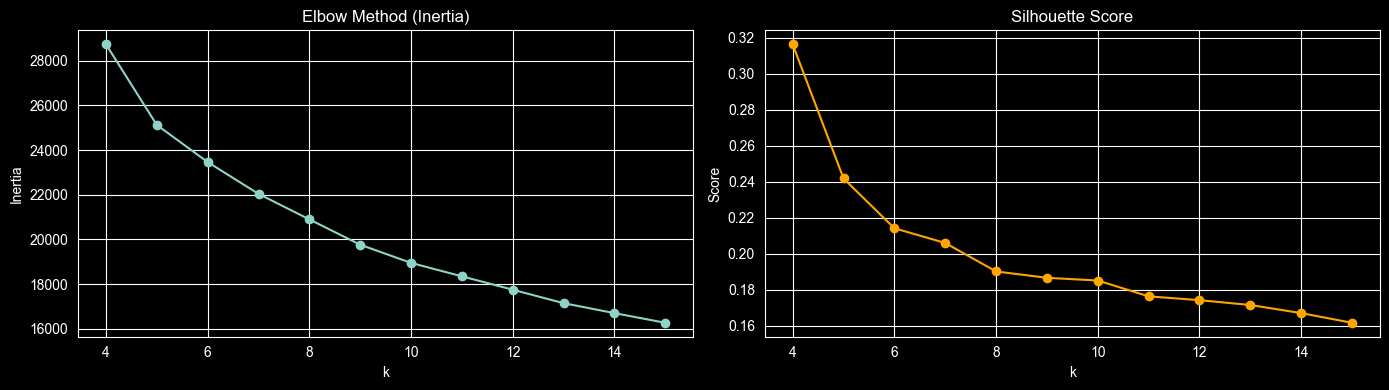

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the number of PCs that explain ~85% variance
N_COMPONENTS = 10   # adjust based on scree plot output

X_reduced = X_pca[:, :N_COMPONENTS]

inertias = []
silhouettes = []
K_range = range(4, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_reduced, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.grid(True)

ax2.plot(K_range, silhouettes, marker='o', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k')
ax2.set_ylabel('Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [30]:
# Set k based on what you saw in Step 13
K = 12   # adjust this after seeing the plots

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_feat['cluster'] = km_final.fit_predict(X_reduced)

print("Players per cluster:\n", df_feat['cluster'].value_counts().sort_index())

Players per cluster:
 cluster
0     142
1      77
2      95
3     136
4     355
5     280
6     217
7     134
8      67
9     190
10     39
11    164
Name: count, dtype: int64


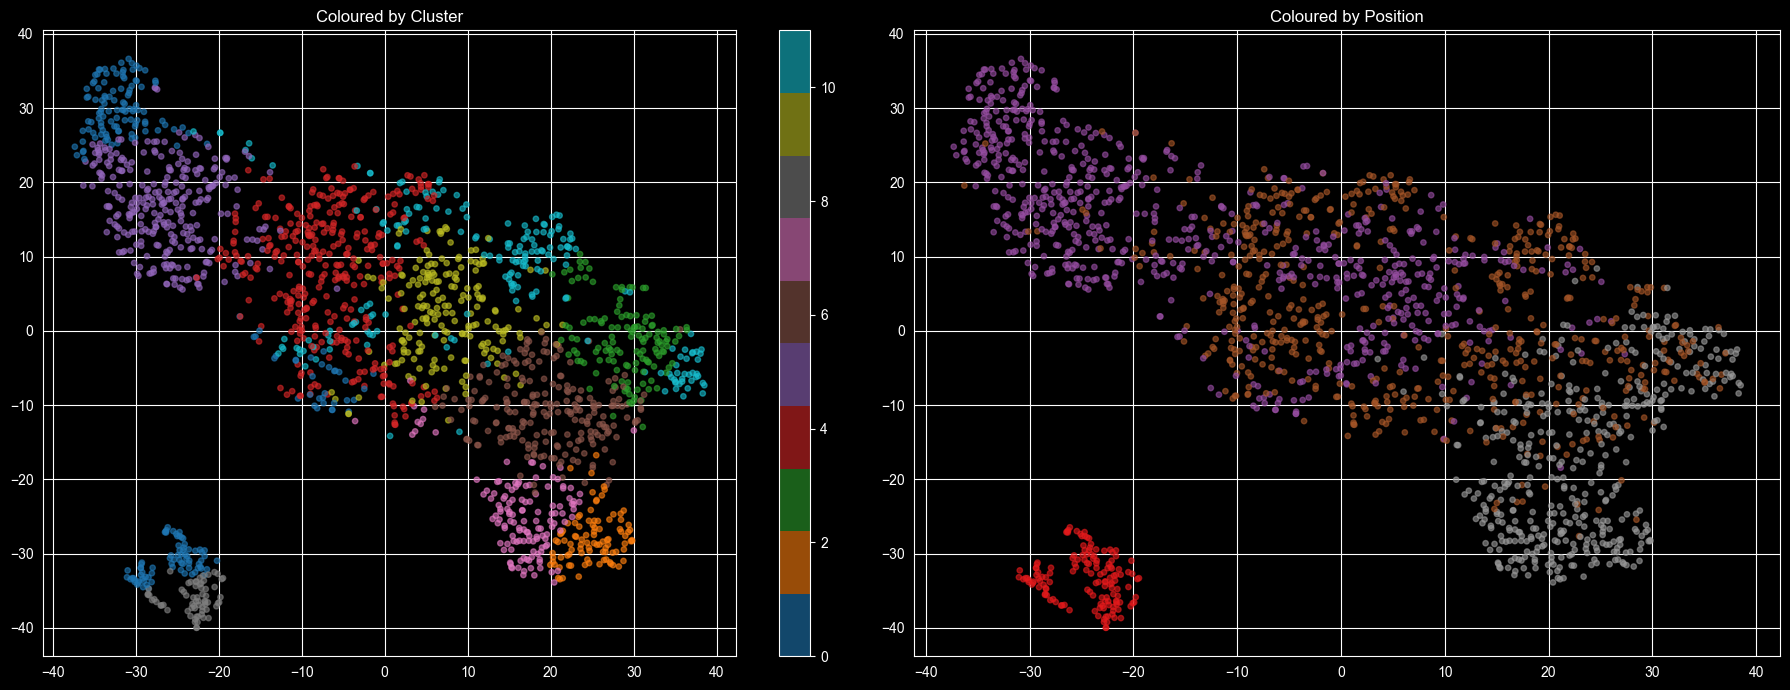

In [31]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_tsne = tsne.fit_transform(X_reduced)

df_feat['tsne_x'] = X_tsne[:, 0]
df_feat['tsne_y'] = X_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot coloured by cluster
scatter1 = ax1.scatter(df_feat['tsne_x'], df_feat['tsne_y'],
                       c=df_feat['cluster'], cmap='tab10', alpha=0.6, s=15)
ax1.set_title('Coloured by Cluster')
plt.colorbar(scatter1, ax=ax1)

# Plot coloured by primary position
pos_map = {'GK': 0, 'DF': 1, 'MF': 2, 'FW': 3}
pos_colors = df_feat['PrimaryPos'].map(pos_map).fillna(4)
scatter2 = ax2.scatter(df_feat['tsne_x'], df_feat['tsne_y'],
                       c=pos_colors, cmap='Set1', alpha=0.6, s=15)
ax2.set_title('Coloured by Position')

plt.tight_layout()
plt.show()


In [32]:
for c in sorted(df_feat['cluster'].unique()):
    group = df_feat[df_feat['cluster'] == c]
    print(f"\n{'='*60}")
    print(f"CLUSTER {c}  ({len(group)} players)")
    print(f"Positions: {group['PrimaryPos'].value_counts().to_dict()}")
    print(f"Sample players: {group['Player'].head(15).tolist()}")
    print(f"Avg Gls/90: {group['Gls_p90'].mean():.2f}  "
          f"Ast/90: {group['Ast_p90'].mean():.2f}  "
          f"Tkl/90: {group['Tkl_p90'].mean():.2f}  "
          f"Int/90: {group['Int_p90'].mean():.2f}  "
          f"Cmp%: {group['Cmp%'].mean():.1f}")



CLUSTER 0  (142 players)
Positions: {'DF': 129, 'MF': 13}
Sample players: ['Nikola Milenković', 'Cristhian Mosquera', 'Marc Guéhi', 'Marten de Roon', 'William Saliba', 'Ola Aina', 'Marc Cucurella', 'Enzo Boyomo', 'Marash Kumbulla', 'Sergi', 'Enrico Del Prato', 'Ezri Konsa', 'Diego Coppola', 'Leandro Cabrera', 'Wout Faes']
Avg Gls/90: 0.11  Ast/90: 0.02  Tkl/90: 1.63  Int/90: 1.09  Cmp%: 85.6

CLUSTER 1  (77 players)
Positions: {'GK': 77}
Sample players: ['Jordan Pickford', 'Joan García', 'Matz Sels', 'David Raya', 'Mile Svilar', 'David Soria', 'Dean Henderson', 'Vanja Milinković-Savić', 'Sergio Herrera', 'Zion Suzuki', 'Mike Maignan', 'Mark Flekken', 'Emiliano Martínez', 'David de Gea', 'Marco Carnesecchi']
Avg Gls/90: 0.00  Ast/90: 0.01  Tkl/90: 0.04  Int/90: 0.01  Cmp%: 72.8

CLUSTER 2  (95 players)
Positions: {'FW': 92, 'MF': 3}
Sample players: ['Nikola Krstović', 'Ante Budimir', 'Yoane Wissa', 'Alexander Isak', 'Tim Kleindienst', 'Erling Haaland', 'Robert Lewandowski', 'Jean-Phili

In [33]:
CLUSTER_LABELS = {
    0:  'Ball-playing Centre-back',
    1:  'Goalkeeper',
    2:  'Clinical Striker',
    3:  'Creative Attacking Midfielder',
    4:  'Defensive Midfielder',
    5:  'Defensive Centre-back',
    6:  'Wide Midfielder / Winger',
    7:  'Target Man / Physical Striker',
    8:  'Goalkeeper',
    9:  'Fullback / Wing-back',
    10: 'Elite Wide Forward',
    11: 'Box-to-box Midfielder',
}

df_feat['role'] = df_feat['cluster'].map(CLUSTER_LABELS)

print("Role distribution:")
print(df_feat['role'].value_counts())


Role distribution:
role
Defensive Midfielder             355
Defensive Centre-back            280
Wide Midfielder / Winger         217
Fullback / Wing-back             190
Box-to-box Midfielder            164
Goalkeeper                       144
Ball-playing Centre-back         142
Creative Attacking Midfielder    136
Target Man / Physical Striker    134
Clinical Striker                  95
Elite Wide Forward                39
Name: count, dtype: int64


In [36]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Anchor feature per role — the one stat that MUST load positively
# If PC1 loads negatively on this feature, flip the scores
ROLE_ANCHORS = {
    'Clinical Striker':                'Gls_p90',
    'Elite Wide Forward':              'Gls_p90',
    'Target Man / Physical Striker':   'Gls_p90',
    'Creative Attacking Midfielder':   'xAG_p90',
    'Wide Midfielder / Winger':        'SCA90',
    'Box-to-box Midfielder':           'Cmp%',       # changed from SCA90
    'Defensive Midfielder':            'Tkl_p90',
    'Ball-playing Centre-back':        'Int_p90',
    'Defensive Centre-back':           'Int_p90',
    'Fullback / Wing-back':            'PrgP_p90',
    'Goalkeeper':                      'PSxG+/-',    # changed from Save%
}


df_feat['overall'] = 0.0

for role, group_idx in df_feat.groupby('role').groups.items():
    group = df_feat.loc[group_idx, FINAL_FEATURES].fillna(0)

    if len(group) < 5:
        continue

    # Z-score within the role group
    scaler_grp = StandardScaler()
    G_scaled = scaler_grp.fit_transform(group)

    # PCA — first component captures most variance
    pca_grp = PCA(n_components=1)
    scores = pca_grp.fit_transform(G_scaled).flatten()

    # Flip check — anchor feature must load positively on PC1
    anchor = ROLE_ANCHORS.get(role)
    if anchor and anchor in FINAL_FEATURES:
        anchor_idx = FINAL_FEATURES.index(anchor)
        if pca_grp.components_[0][anchor_idx] < 0:
            scores = -scores

    # Normalize to 0–100
    min_max = MinMaxScaler(feature_range=(0, 100))
    scores_norm = min_max.fit_transform(scores.reshape(-1, 1)).flatten()

    df_feat.loc[group_idx, 'overall'] = scores_norm

# Sanity check — top 5 per role
for role in sorted(df_feat['role'].unique()):
    top5 = (df_feat[df_feat['role'] == role]
    .nlargest(5, 'overall')[['Player', 'Squad', 'overall']])
    print(f"\n── {role} ──")
    print(top5.to_string(index=False))



── Ball-playing Centre-back ──
         Player          Squad    overall
Matija Nastasić        Leganés 100.000000
 Giovanni Leoni          Parma  94.138011
Domingos Duarte         Getafe  94.034060
   Jan Bednarek    Southampton  93.789855
    Conor Coady Leicester City  92.483069

── Box-to-box Midfielder ──
           Player         Squad    overall
     Ross Barkley   Aston Villa 100.000000
    Adrien Rabiot     Marseille  91.531457
       Jens Stage Werder Bremen  90.980705
   Kamory Doumbia         Brest  89.528610
Aleksandr Golovin        Monaco  85.327541

── Clinical Striker ──
          Player           Squad    overall
Cristhian Stuani          Girona 100.000000
     Andrej Ilic    Union Berlin  94.755332
  Erling Haaland Manchester City  93.941407
    Ante Budimir         Osasuna  93.389855
  Emanuel Emegha      Strasbourg  91.333134

── Creative Attacking Midfielder ──
          Player      Squad    overall
    Nuno Tavares      Lazio 100.000000
   Juan Cuadrado   Atalant